This is the notebook where I tried to optimize the plottings. I added a diccionary to clean up the data processing.

In [6]:
import qcodes as qc
from qcodes.dataset import load_by_id
import matplotlib.pyplot as plt
from qcodes.dataset.experiment_container import experiments
import numpy as np
import pandas as pd
import sif_parser
from scipy.optimize import curve_fit
from scipy.signal import medfilt
import matplotlib.pyplot as plt
import os


In [7]:
#Functions
def gaussian(x, amp, x0, sigma):
    return  amp*np.exp(-(x - x0)**2/(2 * sigma**2))

def lorentzian(x, amp, x0, gamma):
    return amp*gamma**2/((x-x0)**2+gamma**2) 

def pv(x,A,eta,x0,w, offset):
    """
    A: Altura total del pico (sobre el offset)
    x0: Posición central del máximo
    sigma: Anchura de la Gaussiana
    gamma: Anchura de la Lorentziana
    eta: Peso de la Lorentziana (0 = puramente Gaussiana, 1 = puramente Lorentziana)
    offset: Ruido de fondo (línea base)

    """
    sigma = w/2.35482
    gamma=w/2.0
    g = gaussian(x, 1, x0, sigma)
    l = lorentzian(x, 1, x0, gamma)
    return A*(eta*l+(1-eta)*g)+offset
def peak_track(x_data, y, y_mask_fit=0,mode1=True):
    if mode1:
        y_mask_fit=y
    A_guess = np.max(y)-np.min(y)
    x0_guess = x_data[np.argmax(y_mask_fit)]
    offset_guess = np.min(y)
    w_guess=50.0
    p0 = [A_guess, 0.5, x0_guess, w_guess, offset_guess]
    limits = ([0,0,0,0.1, 0],[np.inf, 1, 1600, np.inf, np.inf])
    try:
        popt, pcov = curve_fit(pv, x_data, y, p0=p0, bounds = limits)
        A = popt[0]
        x = popt[2]
    except RuntimeError:
        A = np.nan
        x = np.nan
        print('ERROR: curve_fit failed for this spectrum')
        popt =[np.nan,np.nan,np.nan,np.nan,np.nan]
        pcov=np.nan
    return A, x, popt, pcov 

Diccionary with the different plots. This are all .sif files, it has been created to use database files as well by adding the "sif":False & "id" items. On the extraction loop it has a branch for sif:False.

In [8]:
series = {"monolayer":{"sif":True,
                       "path":r"G:\Mi unidad\Experiments\Materials\CuInP2S6\20251124_HM\WSe2\4_photoluminesence\20260216\010_PL_pdms_514nm_OPO_sweep710_850_10uW_60s_calibrated.sif",
                        "laser":514, #nm
                        "power":10, #uW
                        "exptime": 60, #s
                        "label": 'Monolayer'
                       },

          "bilayer":{"sif":True,
                     "path":r"G:\Mi unidad\Experiments\Materials\CuInP2S6\20251124_HM\WSe2\4_photoluminesence\20260216\009_PL_pdms_514nm_OPO_sweep710_850_10uW_60s_calibrated.sif",
                    "laser":514, #nm
                    "power":10, #uW                    
                    "exptime": 60, #s
                    "label": "Bilayer"

                     },

          "trilayer":{"sif":True,
                      "path":r"G:\Mi unidad\Experiments\Materials\CuInP2S6\20251124_HM\WSe2\4_photoluminesence\20260216\008_z2_PL_pdms_514nm_OPO_sweep710_850_20uW_60s_calibrated.sif",
                    "laser":514, #nm
                    "power":20, #uW
                    "exptime": 60, #s
                    "label": "Trilayer"

                      },
          }

In [9]:
#data readout. We work with 2 types of files. database files from the mapping and .sif from individual scans

for s in series.values():
    if s['sif'] == True:
        data, info = sif_parser.utils.parse(s['path'])
        s['x'] = data[:,0]
        s['y'] = data[:,1]

    elif s['sif'] == False:

        qc.config['core']['db_location'] = s['path']
        dataset = load_by_id(s['id'])
        xr_data = dataset.to_xarray_dataset()

        s['x'] = xr_data['camera_pixel_x_axis'].values
        y_matrix = xr_data['camera_spectrum'].values #this is a matrix (i,j,:) i,j are the points of the mapping
        s['y_matrix'] = y_matrix

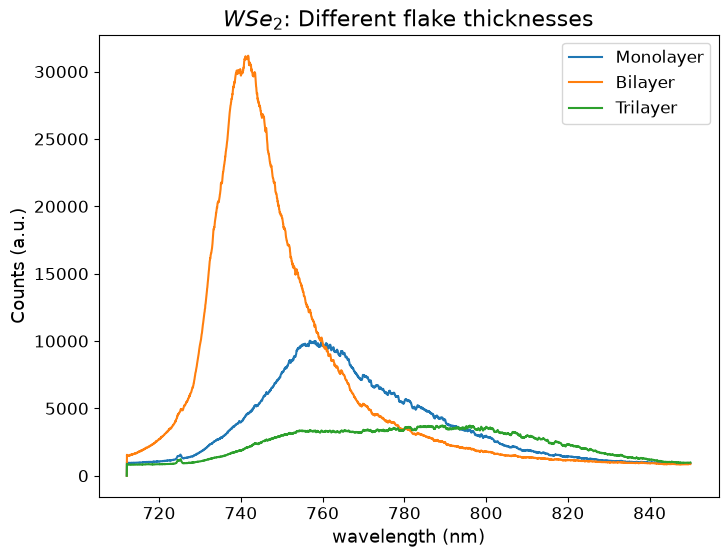

In [ ]:
# Define the Region of Interest (ROI) boundaries for the wavelength (x-axis)
roi_edges = (690, 850)

# Set up the figure and axes for the plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('$WSe_2$: Different flake thicknesses', fontsize=16)

# Loop through each dataset in the 'series' dictionary
for s in series.values():

    # Extract raw wavelength (x) and intensity (y) arrays
    y_raw = s['y']
    x_raw = s['x']

    # Create a boolean mask to isolate data within our ROI limits
    roi = (x_raw > roi_edges[0]) & (x_raw < roi_edges[1])

    # --- Data Cleaning ---
    noise_treshold = 253

    # Use a median filter to create a smoothed version of the data.
    # This acts as a baseline to detect cosmic rays or weird narrow spikes.
    y_template = medfilt(y_raw, kernel_size=51)
    
    # Calculate the difference between the raw data and the smoothed baseline
    dif = y_raw - y_template
    
    # Identify the points where the spike is larger than our allowed threshold
    mask = dif > noise_treshold
    
    # Create a clean copy of the data and replace the spikes with the smoothed values
    y_clean = y_raw.copy()
    y_clean[mask] = y_template[mask]

    # --- Apply ROI Filter ---
    # Crop the datasets down to just the Region of Interest
    y = y_clean[roi]
    x = x_raw[roi]
    y_template = y_template[roi]
    
    y_max = np.max(y)
    
    try:
        # Attempt to fit a curve to the peak
        a, b, popt, pcov = peak_track(x, y, y_mask_fit=y_template, mode1=False)
        
        # Generate the predicted y-values using the fitted parameters (pseudo-Voigt)
        y_fit = pv(x, *popt)
        
        # Calculate the R-squared value to evaluate the goodness of the fit
        residuals = y - y_fit
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        
        # Standardized residuals (optional, useful for debugging/analysis)
        std_residuals = residuals / np.std(residuals) 

        # --- Plotting ---
        # Plot the cleaned raw data for this specific series
        ax.plot(x, y, label=f"{s['label']}")
        
        # Plot the fitted curve (currently commented out)
        # ax.plot(x, y_fit, linewidth=2)

    except RuntimeError:
        # Catch optimization failures if the curve fit can't converge
        print(f"Curve fit failed for {s.get('label', 'unknown sample')}. Skipping fit.")

# Format the plot aesthetics (ticks, labels, and legend)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("wavelength (nm)", fontsize=13)
ax.set_ylabel("Counts (a.u.)", fontsize=13)
ax.legend(fontsize=12)            

# Display the final plot
plt.show()